# Data Pre-Processing

#### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

#### Import csv

In [2]:
df = pd.read_csv("Visadataset.csv")
# Print shape of dataset
print(df.shape)

(25480, 12)


# Data Cleaning

### Handling Missing values

In [3]:
df.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

### Other Data Cleaning steps

In [4]:
df.duplicated().sum()

np.int64(0)

**Removing case_id from dataset as it not useful for model training**

In [5]:
df.drop('case_id',inplace=True,axis=1)

# Feature Engineering

## Feature Extraction

In [6]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Subtract current year with yr_of_estab to get company's age**

In [7]:
from datetime import date
today_year = date.today().year
df['company_age'] = today_year - df.yr_of_estab
df.drop('yr_of_estab',inplace=True,axis=1)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


**Split X and y**

In [8]:
X = df.drop('case_status',axis=1)
y = df['case_status']

Let's manually encode target column

In [9]:
#1 for denied and 0 for certified
y = np.where(y=='Denied',1,0)
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

## Feature Transformation

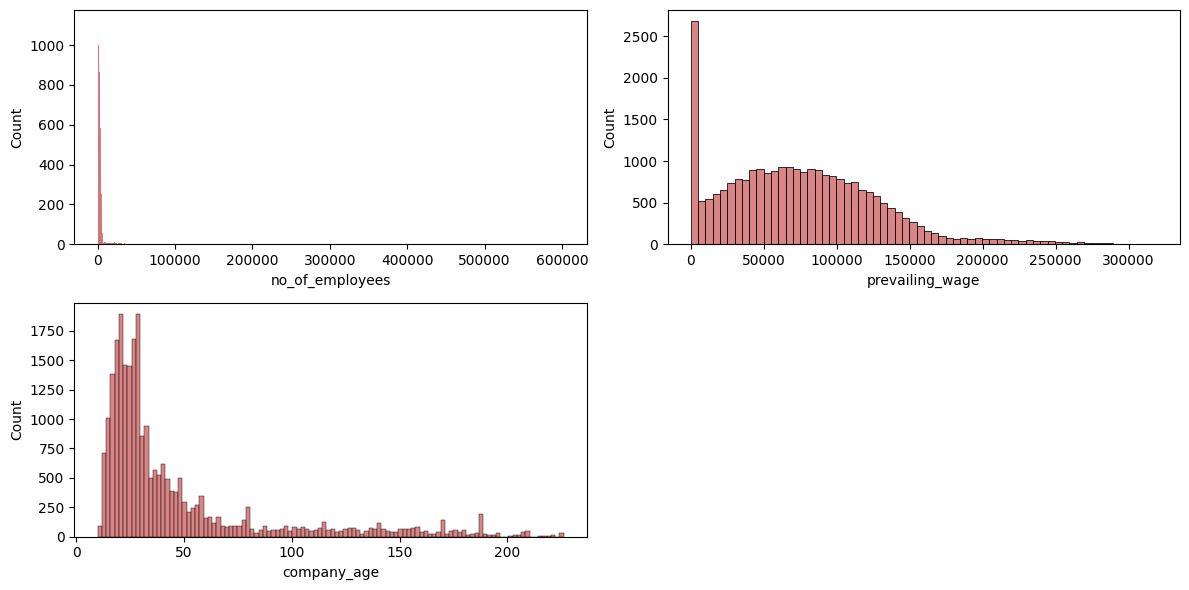

In [10]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

no_of_employees and company_age columns are skewed. We need to fix this.

**Let's check skewness**

In [11]:
categorical_col = [l for l in X.columns if X[l].dtype=='O']
categorical_col

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position']

In [12]:
numerical_col = [l for l in X.columns if X[l].dtype!='O']
numerical_col

['no_of_employees', 'prevailing_wage', 'company_age']

In [13]:
X[numerical_col].skew()

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

As we can see no_of_employees and company_age are skewed

Let's apply power transformation using yeo-jonhson method

In [14]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])

In [15]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)
X_copy.head()

,company_age,no_of_employees
0,-0.958506,1.517300
1,-0.470816,0.030912
2,-1.080479,2.885076
3,1.632700,-1.343550
4,-0.741917,-0.432287


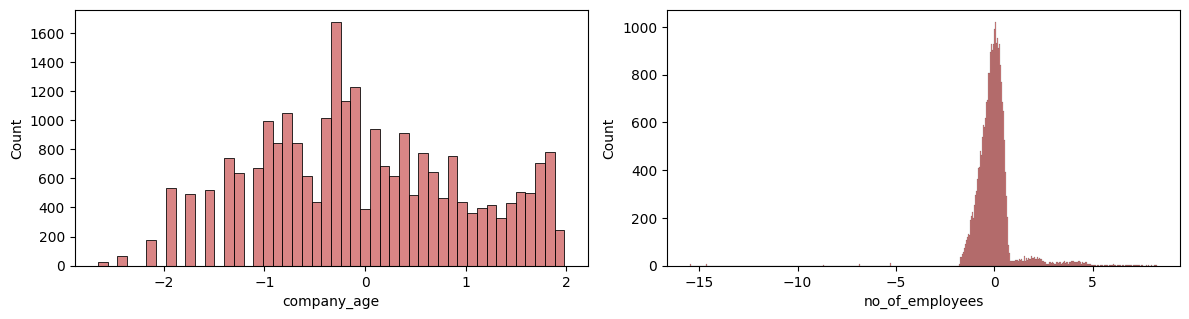

In [16]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(X_copy.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [17]:
X_copy.skew()

company_age        0.120823
no_of_employees    0.399339
dtype: float64

In [18]:
X.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,21


Here we are going to set a column transformer pipeline that will ensure:

-one hot encoding for columns having lesser unique values and not ordinal

-ordinal encoding for columns having many unique values

-power transformation to fix skewness

-standard scaler to scale features


In [44]:
transform_features = ['company_age', 'no_of_employees']
one_hot_features = ['continent','unit_of_wage','region_of_employment']
ordinal_features = ['education_of_employee']
binary_features = ['full_time_position', 'has_job_experience', 'requires_job_training'] # we could have added these features into ordinal features but since they are binary, we will get the same result.
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
import category_encoders as ce

scaler = StandardScaler()
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
ordinal_encoder = OrdinalEncoder()
binary_encoder = ce.BinaryEncoder()

'''transform_pipeline = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])'''


preprocessor = ColumnTransformer(transformers=[
    ('OneHotEncoder', one_hot_encoder, one_hot_features),
    ('OrdinalEncoder', ordinal_encoder, ordinal_features),
    ('Transformer', PowerTransformer(method='yeo-johnson'), transform_features),
    ('BinaryEncoder', binary_encoder, binary_features),
    ('StandardScaler', scaler, numerical_col)
])

**Before applying preprocessing let's split our dataset to avoid data leakage**

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [47]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([13614,  6770]))

**we notice a class imbalance, let's apply resampling with smoteenn method**

In [48]:
from imblearn.combine import SMOTETomek, SMOTEENN

smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
X_res, y_res = smt.fit_resample(X_train_transformed, y_train)

## Model training

In [49]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [50]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [51]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [52]:
def evaluate_models(X_train, y_train, X_test, y_test, models):
    '''
    This function iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    
    models_list = []
    accuracy_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report

In [53]:
base_model_report = evaluate_models(X_train=X_res, y_train=y_res, X_test=X_test_transformed, y_test=y_test, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6986
- F1 score: 0.5973
- Precision: 0.5368
- Recall: 0.6732
- Roc Auc Score: 0.6922


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6799
- F1 score: 0.5861
- Precision: 0.5136
- Recall: 0.6826
- Roc Auc Score: 0.6806


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8976
- F1 score: 0.9045
- Precision: 0.9124
- Recall: 0.8967
- Roc Auc Score: 0.8977
----------------------------------
Model performance for Test set
- Accuracy: 0.7049
- F1 score: 0.6189
- Precision: 0.5417
- Recall: 0.7216
- Roc Auc Score: 0.7091


Logistic Regression
Model performance for Training 

In [ ]:
base_model_report = evaluate_models(X_train=X_train_transformed, y_train=y_train, X_test=X_test_transformed, y_test=y_test, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7143
- F1 score: 0.5124
- Precision: 0.5912
- Recall: 0.4521
- Roc Auc Score: 0.6484


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6491
- F1 score: 0.4760
- Precision: 0.4721
- Recall: 0.4799
- Roc Auc Score: 0.6066


Gradient Boosting
Model performance for Training set
- Accuracy: 0.7557
- F1 score: 0.5912
- Precision: 0.6655
- Recall: 0.5319
- Roc Auc Score: 0.6995
----------------------------------
Model performance for Test set
- Accuracy: 0.7408
- F1 score: 0.5679
- Precision: 0.6359
- Recall: 0.5130
- Roc Auc Score: 0.6835


Logistic Regression
Model performance for Training 

In [54]:
base_model_report

,Model Name,Accuracy
6,CatBoosting Classifier,0.712520
5,XGBClassifier,0.708399
2,Gradient Boosting,0.704867
0,Random Forest,0.698587
1,Decision Tree,0.679945
7,Support Vector Classifier,0.676413
8,AdaBoost Classifier,0.672488
4,K-Neighbors Classifier,0.661499
3,Logistic Regression,0.615188


-we notice serious overfitting with tree based models, the gap between train and test accuracies is huge. that's why we are going to focus on models with slightly identical accuracy both in train and test. and then also focus on recall and f1 score.

-We discover that when we got low recall on test set, it’s because of imbalance class in dataset. Using resampling helps to get better recall (but accuracy decreases slightly), so the model predicts also the minority class.

**so we're going to move with gradient boosting, catboost and xgboost.**

In [57]:
randomcv_models = [

    (
        "GradientBoosting",
        Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 200, 300, 500],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 1.0]
        }
    ),

    (
        "XGBoost",
        Pipeline([
            ("model", XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                use_label_encoder=False
            ))
        ]),
        {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [3, 5, 7, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.8, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 1.0],
            "model__gamma": [0, 0.1, 0.3]
        }
    ),

    (
        "CatBoost",
        Pipeline([
            ("model", CatBoostClassifier(
                random_state=42,
                verbose=0
            ))
        ]),
        {
            "model__iterations": [200, 400, 600],
            "model__depth": [4, 6, 8, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__l2_leaf_reg": [1, 3, 5, 7]
        }
    )
]

In [58]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
best_models = {}

for name, model, params in randomcv_models:

    print(f"Running RandomizedSearchCV for {name}...")

    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        scoring="f1",   # IMPORTANT for imbalance
        verbose=2,
        n_jobs=-1,
        random_state=42
    )

    random.fit(X_res, y_res)

    model_param[name] = random.best_params_
    best_models[name] = random.best_estimator_

Running RandomizedSearchCV for GradientBoosting...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Running RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Running RandomizedSearchCV for CatBoost...
Fitting 3 folds for each of 100 candidates, totalling 300 fits


In [59]:
for model_name in model_param:
    print(f"\n---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])


---------------- Best Params for GradientBoosting -------------------
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.2}

---------------- Best Params for XGBoost -------------------
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 1.0}

---------------- Best Params for CatBoost -------------------
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 400, 'model__depth': 10}


In [67]:
from sklearn.metrics import classification_report

for name, model in best_models.items():
    print(f"\n===== {name} =====")
    y_pred = model.predict(X_test_transformed)
    print(classification_report(y_test, y_pred))


===== GradientBoosting =====
              precision    recall  f1-score   support

           0       0.81      0.74      0.78      3404
           1       0.56      0.66      0.61      1692

    accuracy                           0.71      5096
   macro avg       0.69      0.70      0.69      5096
weighted avg       0.73      0.71      0.72      5096


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.82      0.71      0.76      3404
           1       0.54      0.68      0.60      1692

    accuracy                           0.70      5096
   macro avg       0.68      0.70      0.68      5096
weighted avg       0.73      0.70      0.71      5096


===== CatBoost =====
              precision    recall  f1-score   support

           0       0.82      0.71      0.76      3404
           1       0.54      0.68      0.60      1692

    accuracy                           0.70      5096
   macro avg       0.68      0.70      0.68      5096
w

In [63]:
X_test

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,company_age
4863,South America,High School,Y,N,3614,West,74251.8500,Year,Y,28
1734,Asia,High School,N,N,1250,South,74515.6600,Year,N,107
3600,North America,Master's,Y,N,6082,West,33143.8100,Year,Y,28
6819,Asia,Bachelor's,Y,N,2277,South,61816.8500,Year,Y,70
23846,Europe,Bachelor's,N,N,540,South,853.9335,Hour,Y,19
...,...,...,...,...,...,...,...,...,...,...
10356,Asia,Bachelor's,Y,N,1858,West,25790.8900,Year,Y,20
15756,Asia,Master's,Y,N,1308,West,56492.8400,Year,Y,24
7716,Asia,High School,N,Y,1985,West,41351.1000,Year,Y,47
13020,Asia,Master's,Y,N,16363,Island,15284.0200,Year,Y,42


In [64]:
X_test.continent.value_counts()

continent
Asia             3361
Europe            759
North America     657
South America     166
Africa            107
Oceania            46
Name: count, dtype: int64